Dataset Shape: (6362620, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  

Missing Values:
step              0
type              0
amount            0

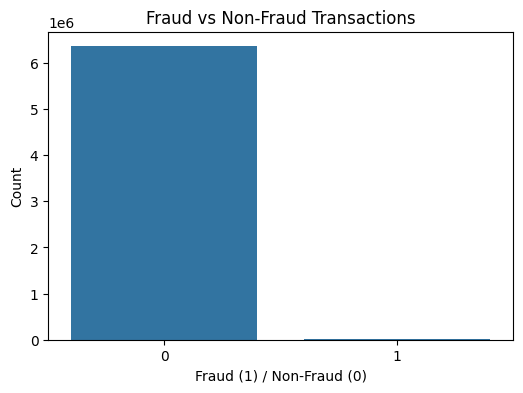

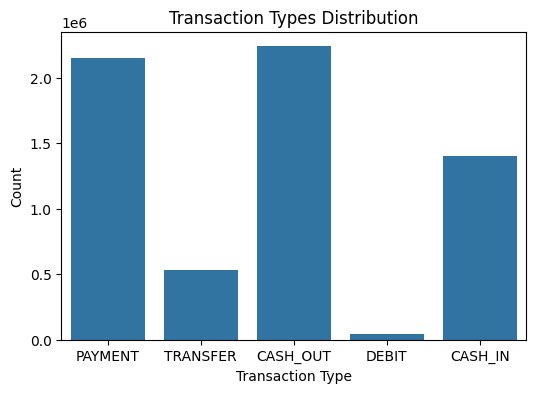

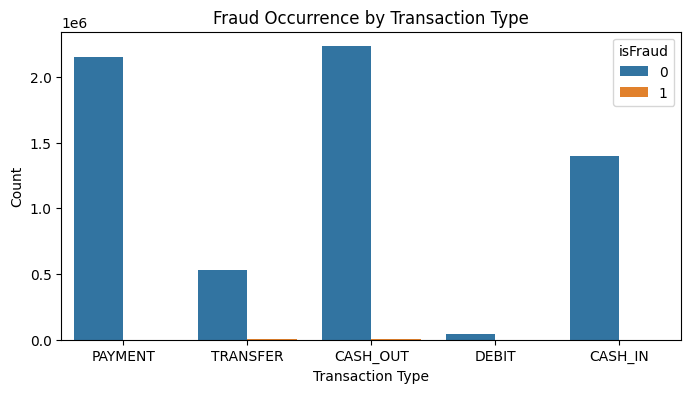

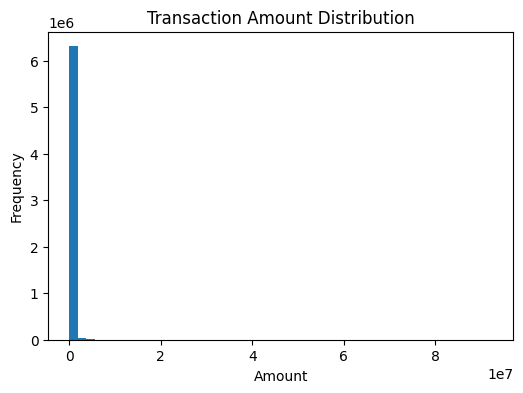

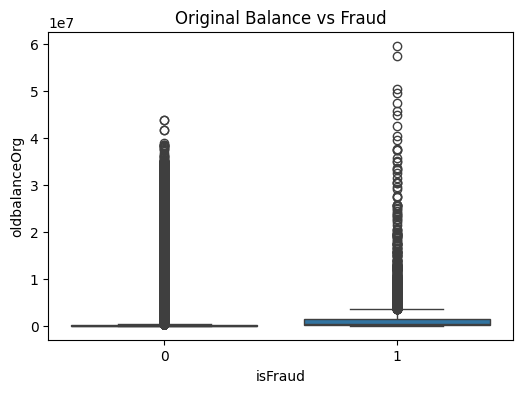

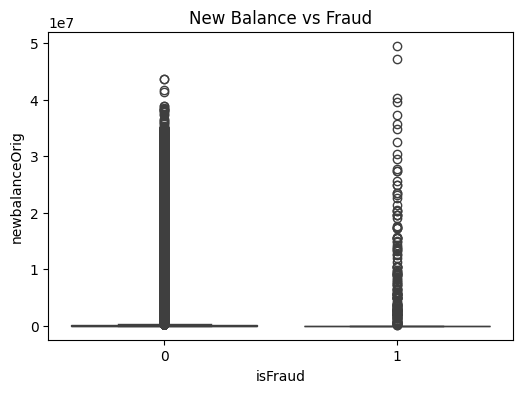

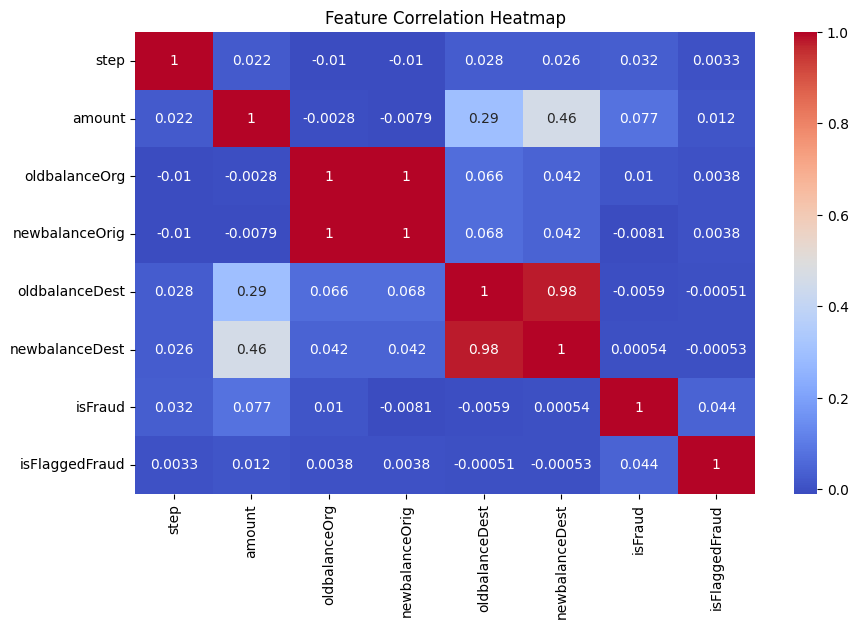


Fraud Ratio:
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64
Balanced Data Shape: (16426, 11)
Training Samples: (13140, 7)
Testing Samples: (3286, 7)

Logistic Regression
Accuracy: 0.9184418746195983

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      1643
           1       0.94      0.89      0.92      1643

    accuracy                           0.92      3286
   macro avg       0.92      0.92      0.92      3286
weighted avg       0.92      0.92      0.92      3286


Confusion Matrix:
[[1557   86]
 [ 182 1461]]

Random Forest
Accuracy: 0.9936092513694461

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1643
           1       0.99      1.00      0.99      1643

    accuracy                           0.99      3286
   macro avg       0.99      0.99      0.99      3286
weighted avg       0.99      0.99      0.

In [ ]:
# =========================
# Financial Fraud Detection
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ==========================================
# 1. Load Dataset
# ==========================================

df = pd.read_csv("/content/Fraud.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ==========================================
# 2. EDA
# ==========================================

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# ------------------------------------------
#  Dataset Overview
# ------------------------------------------

print("Dataset Shape:", df.shape)
print("\nDataset Columns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

# ------------------------------------------
# Missing Values
# ------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())

# ------------------------------------------
# Class Distribution (Fraud vs Non-Fraud)
# ------------------------------------------

print("\nFraud Distribution:")
print(df['isFraud'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud (1) / Non-Fraud (0)")
plt.ylabel("Count")
plt.show()

# ------------------------------------------
# Transaction Type Distribution
# ------------------------------------------

plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Transaction Types Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

# ------------------------------------------
# Fraud by Transaction Type
# ------------------------------------------

plt.figure(figsize=(8,4))
sns.countplot(x='type', hue='isFraud', data=df)
plt.title("Fraud Occurrence by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

# ------------------------------------------
# Transaction Amount Distribution
# ------------------------------------------

plt.figure(figsize=(6,4))
plt.hist(df['amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------
# Balance Comparison
# ------------------------------------------

plt.figure(figsize=(6,4))
sns.boxplot(x='isFraud', y='oldbalanceOrg', data=df)
plt.title("Original Balance vs Fraud")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='isFraud', y='newbalanceOrig', data=df)
plt.title("New Balance vs Fraud")
plt.show()

# ------------------------------------------
# Correlation Analysis
# ------------------------------------------

numeric_df = df.select_dtypes(include=['float64','int64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# ==========================================
# 3. Handle Imbalanced Data
# ==========================================

print("\nFraud Ratio:")
print(df['isFraud'].value_counts(normalize=True))

# Undersampling for simplicity
fraud = df[df['isFraud']==1]
normal = df[df['isFraud']==0].sample(len(fraud), random_state=42)

df_balanced = pd.concat([fraud, normal])

print("Balanced Data Shape:", df_balanced.shape)

# ==========================================
# 4. Feature Selection
# ==========================================

# Drop unnecessary columns
df_balanced = df_balanced.drop(['nameOrig','nameDest','isFlaggedFraud'], axis=1)

# Encode transaction type
encoder = LabelEncoder()
df_balanced['type'] = encoder.fit_transform(df_balanced['type'])

# Features and target
X = df_balanced.drop('isFraud', axis=1)
y = df_balanced['isFraud']

# ==========================================
# 5. Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

# ==========================================
# 6. Machine Learning Models
# ==========================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

for name, model in models.items():

    print("\n==============================")
    print(name)
    print("==============================")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

In [ ]:
!pip install torch torchvision torchaudio
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.1 MB/s eta 0:00:00


In [ ]:
# ==========================================
# Graph Neural Network for Fraud Detection
# ==========================================

import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import torch.nn.functional as F

# ==========================================
# 1. Load Dataset
# ==========================================

df = pd.read_csv("Fraud.csv")

# Optional: Reduce size for faster training
df = df.sample(50000, random_state=42)

# ==========================================
# 2. Preprocessing
# ==========================================

# Encode transaction type
encoder = LabelEncoder()
df['type'] = encoder.fit_transform(df['type'])

# Select features
features = ['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
            'oldbalanceDest', 'newbalanceDest']

X = torch.tensor(df[features].values, dtype=torch.float)
y = torch.tensor(df['isFraud'].values, dtype=torch.long)

# ==========================================
# 3. Build Graph (Simple)
# ==========================================

# Create edges based on transactions (sender → receiver)
# Convert IDs to numeric
le_orig = LabelEncoder()
le_dest = LabelEncoder()

df['orig_id'] = le_orig.fit_transform(df['nameOrig'])
df['dest_id'] = le_dest.fit_transform(df['nameDest'])

edge_index = torch.tensor(
    [df['orig_id'].values, df['dest_id'].values],
    dtype=torch.long
)

# ==========================================
# 4. Create Graph Data Object
# ==========================================

data = Data(x=X, edge_index=edge_index, y=y)

# Train-test mask
num_nodes = data.num_nodes
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_idx, test_idx = train_test_split(
    range(num_nodes),
    test_size=0.2,
    random_state=42,
    stratify=y.numpy()
)

train_mask[train_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.test_mask = test_mask

# ==========================================
# 5. GCN Model
# ==========================================

class GCN(torch.nn.Module):
    def __init__(self):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(X.shape[1], 16)
        self.conv2 = GCNConv(16, 2)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)

# ==========================================
# 6. Train Model
# ==========================================

model = GCN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(20):
    model.train()
    optimizer.zero_grad()

    out = model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch}, Loss: {loss.item()}")

# ==========================================
# 7. Evaluation
# ==========================================

model.eval()
pred = model(data).argmax(dim=1)

correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
acc = int(correct) / int(data.test_mask.sum())

print("\nGNN Accuracy:", acc)

/tmp/ipykernel_13498/3503206039.py:50: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  edge_index = torch.tensor(


Epoch 0, Loss: 47313.46875
Epoch 1, Loss: 487.76690673828125
Epoch 2, Loss: 689.3225708007812
Epoch 3, Loss: 846.0275268554688
Epoch 4, Loss: 974.349609375
Epoch 5, Loss: 1081.635009765625
Epoch 6, Loss: 1172.7667236328125
Epoch 7, Loss: 1251.099853515625
Epoch 8, Loss: 1318.904541015625
Epoch 9, Loss: 1377.758544921875
Epoch 10, Loss: 1428.971923828125
Epoch 11, Loss: 1473.495849609375
Epoch 12, Loss: 1512.208251953125
Epoch 13, Loss: 1545.5997314453125
Epoch 14, Loss: 1574.32568359375
Epoch 15, Loss: 1599.0576171875
Epoch 16, Loss: 1620.2674560546875
Epoch 17, Loss: 1638.372802734375
Epoch 18, Loss: 1653.5552978515625
Epoch 19, Loss: 1666.0350341796875

GNN Accuracy: 0.9986



========== Logistic Regression ==========


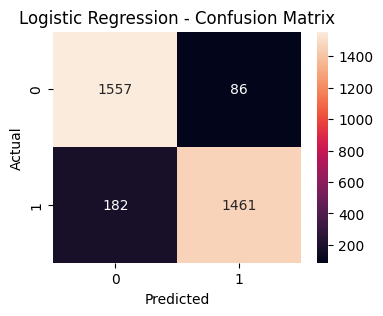

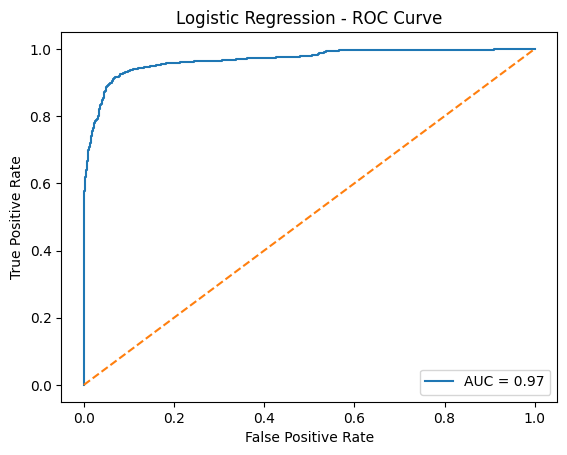

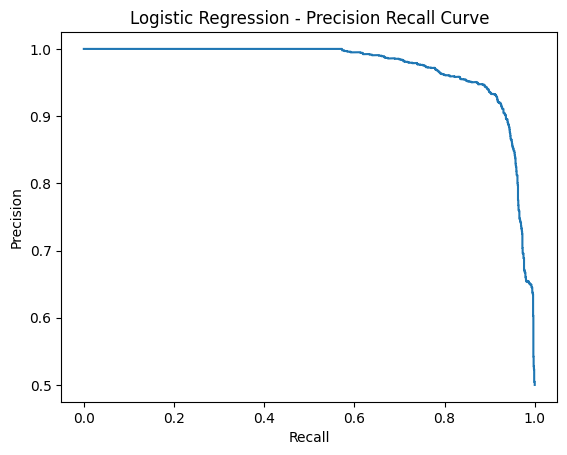


========== Random Forest ==========


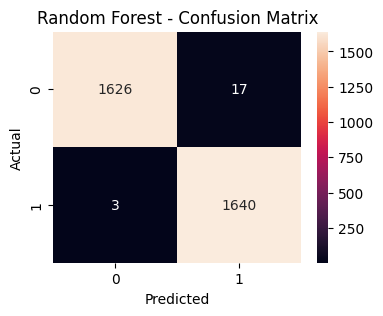

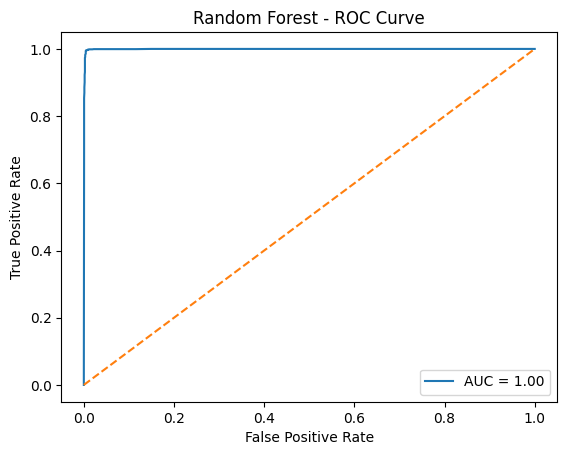

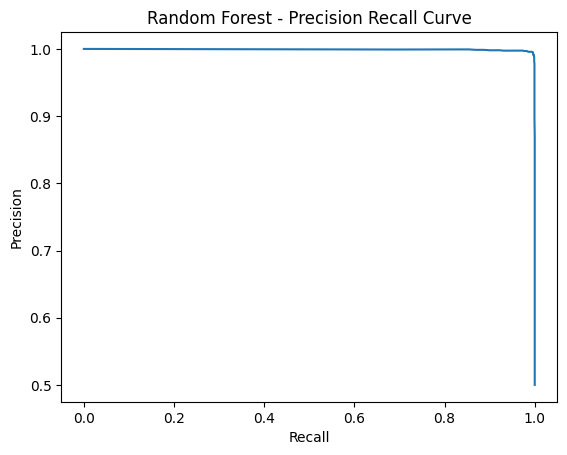


========== XGBoost ==========


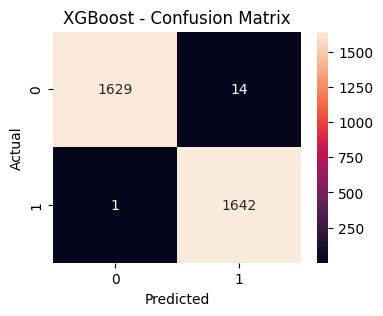

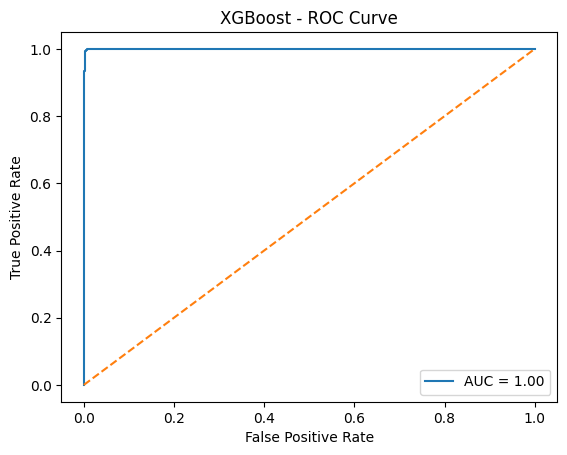

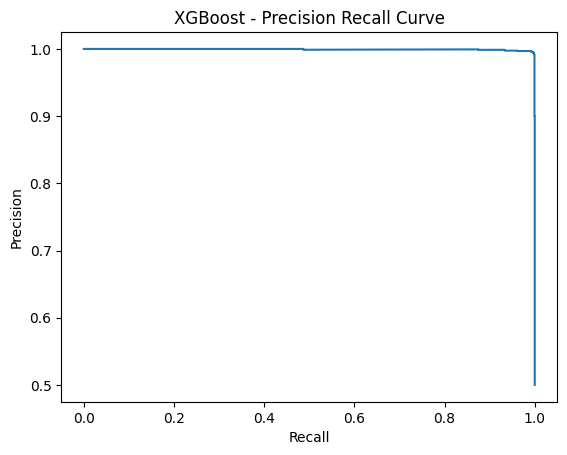

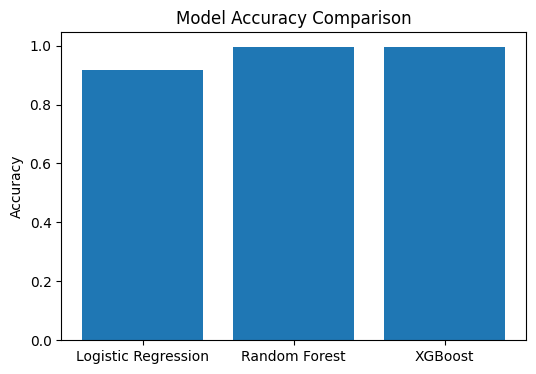

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

results = {}

for name, model in models.items():
    print(f"\n========== {name} ==========")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    # Store accuracy for comparison
    results[name] = accuracy_score(y_test, y_pred)

    # -------- Confusion Matrix --------
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # -------- ROC Curve --------
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.title(f"{name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    # -------- Precision-Recall Curve --------
    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    plt.figure()
    plt.plot(recall, precision)
    plt.title(f"{name} - Precision Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()


# -------- Model Comparison --------
plt.figure(figsize=(6,4))
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()